# Chapter 9.8: Cost-Efficient Training for Recommendation Systems

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Design** checkpoint strategies for fault-tolerant training on spot/preemptible instances
2. **Implement** elastic training with dynamic worker scaling and adaptive batch sizes
3. **Analyze** training budget optimization through cost-per-quality-improvement curves
4. **Apply** importance-based feature pruning to reduce training costs
5. **Understand** model pruning during training via the Lottery Ticket Hypothesis for rec models
6. **Integrate** cost-aware early stopping that balances model quality against compute spend
7. **Build** end-to-end elastic training simulations with checkpoint-resume and cost tracking

## Prerequisites

- Understanding of distributed training concepts (Chapter 9.2)
- Familiarity with HPO and training efficiency (Chapter 9.7)
- Basic knowledge of cloud computing pricing models
- PyTorch fundamentals

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part9/chapter_9.8_cost_efficient.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/blob/main/notebooks/part9/chapter_9.8_cost_efficient.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
import copy
import json
import os
from typing import List, Dict, Tuple, Optional, Callable
from collections import defaultdict
from dataclasses import dataclass, field

np.random.seed(42)
torch.manual_seed(42)

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")

All imports successful!
PyTorch version: 2.2.2


## 1. Spot/Preemptible Instances for Training

Cloud providers offer **spot instances** (AWS) / **preemptible VMs** (GCP) at 60-90% discount compared to on-demand pricing. The catch: they can be reclaimed with little notice (typically 30s-2min warning).

| Instance Type | Cost ($/hr, approximate) | Discount | Interruption Risk |
|---------------|--------------------------|----------|-------------------|
| On-demand GPU | $3.00 | 0% | None |
| Reserved GPU (1yr) | $1.80 | ~40% | None |
| Spot/Preemptible GPU | $0.90 | ~70% | Medium-High |

### Checkpoint Strategies for Fault Tolerance

The key to using spot instances is **frequent, efficient checkpointing**. The optimal checkpoint interval balances:

$$C_{\text{total}} = C_{\text{compute}} + C_{\text{checkpoint}} + C_{\text{recovery}}$$

The optimal checkpoint frequency (Young's Rule, adapted):

$$\Delta t_{\text{ckpt}}^* = \sqrt{2 \cdot \delta \cdot M}$$

where $\delta$ is the time to write one checkpoint and $M$ is the mean time between failures (MTBF).

> **💡 Key Insight:** For rec model training on spot instances, the embedding tables are often the largest part of the checkpoint. Incremental checkpointing (saving only modified embeddings) can reduce checkpoint size by 10-100x.

In [2]:
@dataclass
class CheckpointConfig:
    """Configuration for checkpoint strategy."""
    interval_steps: int = 100        # Steps between checkpoints
    max_checkpoints_kept: int = 3    # Rolling window of checkpoints
    incremental: bool = False        # Only save modified parameters
    checkpoint_time_sec: float = 5.0 # Time to write one checkpoint


@dataclass
class SpotInstanceConfig:
    """Configuration for spot instance simulation."""
    cost_per_hour: float = 0.90       # $/hr for spot
    on_demand_cost: float = 3.00      # $/hr for on-demand (comparison)
    mean_time_between_failures: float = 3600.0  # MTBF in seconds
    preemption_warning_sec: float = 30.0         # Warning before termination
    restart_overhead_sec: float = 120.0          # Time to restart training


class SpotTrainingSimulator:
    """Simulates training on spot instances with checkpointing."""
    
    def __init__(self, total_steps: int, step_time_sec: float,
                 ckpt_config: CheckpointConfig, spot_config: SpotInstanceConfig,
                 seed: int = 42):
        self.total_steps = total_steps
        self.step_time_sec = step_time_sec
        self.ckpt_config = ckpt_config
        self.spot_config = spot_config
        self.rng = np.random.RandomState(seed)
        
    def _sample_failure_time(self) -> float:
        """Sample time until next spot preemption (exponential distribution)."""
        return self.rng.exponential(self.spot_config.mean_time_between_failures)
    
    def simulate(self) -> Dict:
        """Run full training simulation. Returns detailed cost/time metrics."""
        current_step = 0
        last_checkpoint_step = 0
        total_wall_time = 0.0
        total_compute_time = 0.0
        total_checkpoint_time = 0.0
        total_wasted_compute = 0.0
        num_preemptions = 0
        num_checkpoints = 0
        restart_overhead_total = 0.0
        
        history = []  # (wall_time, step, event)
        
        while current_step < self.total_steps:
            # Sample when the next preemption occurs
            time_until_failure = self._sample_failure_time()
            
            # How many steps can we complete before failure?
            steps_possible = int(time_until_failure / self.step_time_sec)
            steps_remaining = self.total_steps - current_step
            
            # Also account for periodic checkpointing overhead
            steps_between_ckpt = self.ckpt_config.interval_steps
            
            steps_done = 0
            preempted = False
            elapsed_in_session = 0.0
            
            while steps_done < steps_possible and current_step + steps_done < self.total_steps:
                # Train one step
                steps_done += 1
                elapsed_in_session += self.step_time_sec
                total_compute_time += self.step_time_sec
                
                # Check if we should checkpoint
                global_step = current_step + steps_done
                if global_step % steps_between_ckpt == 0:
                    elapsed_in_session += self.ckpt_config.checkpoint_time_sec
                    total_checkpoint_time += self.ckpt_config.checkpoint_time_sec
                    last_checkpoint_step = global_step
                    num_checkpoints += 1
                    history.append((total_wall_time + elapsed_in_session,
                                    global_step, 'checkpoint'))
                
                # Check if preemption occurs
                if elapsed_in_session >= time_until_failure:
                    preempted = True
                    break
            
            total_wall_time += elapsed_in_session
            
            if preempted:
                num_preemptions += 1
                # Lose work since last checkpoint
                steps_lost = (current_step + steps_done) - last_checkpoint_step
                wasted = steps_lost * self.step_time_sec
                total_wasted_compute += wasted
                
                history.append((total_wall_time, current_step + steps_done, 'preemption'))
                
                # Restart from last checkpoint
                current_step = last_checkpoint_step
                total_wall_time += self.spot_config.restart_overhead_sec
                restart_overhead_total += self.spot_config.restart_overhead_sec
                
                history.append((total_wall_time, current_step, 'restart'))
            else:
                current_step += steps_done
        
        # Final checkpoint
        total_checkpoint_time += self.ckpt_config.checkpoint_time_sec
        total_wall_time += self.ckpt_config.checkpoint_time_sec
        
        spot_cost = (total_wall_time / 3600) * self.spot_config.cost_per_hour
        on_demand_time = self.total_steps * self.step_time_sec
        on_demand_cost = (on_demand_time / 3600) * self.spot_config.on_demand_cost
        
        return {
            'total_wall_time_sec': total_wall_time,
            'total_compute_time_sec': total_compute_time,
            'total_checkpoint_time_sec': total_checkpoint_time,
            'total_wasted_compute_sec': total_wasted_compute,
            'restart_overhead_sec': restart_overhead_total,
            'num_preemptions': num_preemptions,
            'num_checkpoints': num_checkpoints,
            'spot_cost': spot_cost,
            'on_demand_cost': on_demand_cost,
            'cost_savings': 1.0 - spot_cost / on_demand_cost,
            'overhead_ratio': total_wall_time / on_demand_time,
            'history': history
        }


# Simulate training with different checkpoint intervals
print("=" * 65)
print("Spot Instance Training Simulation")
print("=" * 65)

spot_cfg = SpotInstanceConfig(
    cost_per_hour=0.90, on_demand_cost=3.00,
    mean_time_between_failures=1800,  # 30-min average uptime
    restart_overhead_sec=60.0
)

results_by_interval = {}
for ckpt_interval in [50, 100, 200, 500, 1000]:
    ckpt_cfg = CheckpointConfig(
        interval_steps=ckpt_interval,
        checkpoint_time_sec=3.0
    )
    sim = SpotTrainingSimulator(
        total_steps=5000, step_time_sec=0.5,
        ckpt_config=ckpt_cfg, spot_config=spot_cfg, seed=42
    )
    result = sim.simulate()
    results_by_interval[ckpt_interval] = result
    
    print(f"\nCheckpoint every {ckpt_interval} steps:")
    print(f"  Preemptions: {result['num_preemptions']}")
    print(f"  Checkpoints written: {result['num_checkpoints']}")
    print(f"  Wasted compute: {result['total_wasted_compute_sec']:.0f}s")
    print(f"  Wall time: {result['total_wall_time_sec']:.0f}s "
          f"(vs {5000*0.5:.0f}s on-demand)")
    print(f"  Cost: ${result['spot_cost']:.2f} "
          f"(vs ${result['on_demand_cost']:.2f} on-demand, "
          f"savings: {result['cost_savings']:.1%})")

Spot Instance Training Simulation

Checkpoint every 50 steps:
  Preemptions: 1
  Checkpoints written: 100
  Wasted compute: 5s
  Wall time: 2868s (vs 2500s on-demand)
  Cost: $0.72 (vs $2.08 on-demand, savings: 65.6%)

Checkpoint every 100 steps:
  Preemptions: 1
  Checkpoints written: 50
  Wasted compute: 0s
  Wall time: 2713s (vs 2500s on-demand)
  Cost: $0.68 (vs $2.08 on-demand, savings: 67.4%)

Checkpoint every 200 steps:
  Preemptions: 1
  Checkpoints written: 25
  Wasted compute: 21s
  Wall time: 2659s (vs 2500s on-demand)
  Cost: $0.66 (vs $2.08 on-demand, savings: 68.1%)

Checkpoint every 500 steps:
  Preemptions: 1
  Checkpoints written: 10
  Wasted compute: 86s
  Wall time: 2679s (vs 2500s on-demand)
  Cost: $0.67 (vs $2.08 on-demand, savings: 67.9%)

Checkpoint every 1000 steps:
  Preemptions: 1
  Checkpoints written: 5
  Wasted compute: 342s
  Wall time: 2920s (vs 2500s on-demand)
  Cost: $0.73 (vs $2.08 on-demand, savings: 65.0%)


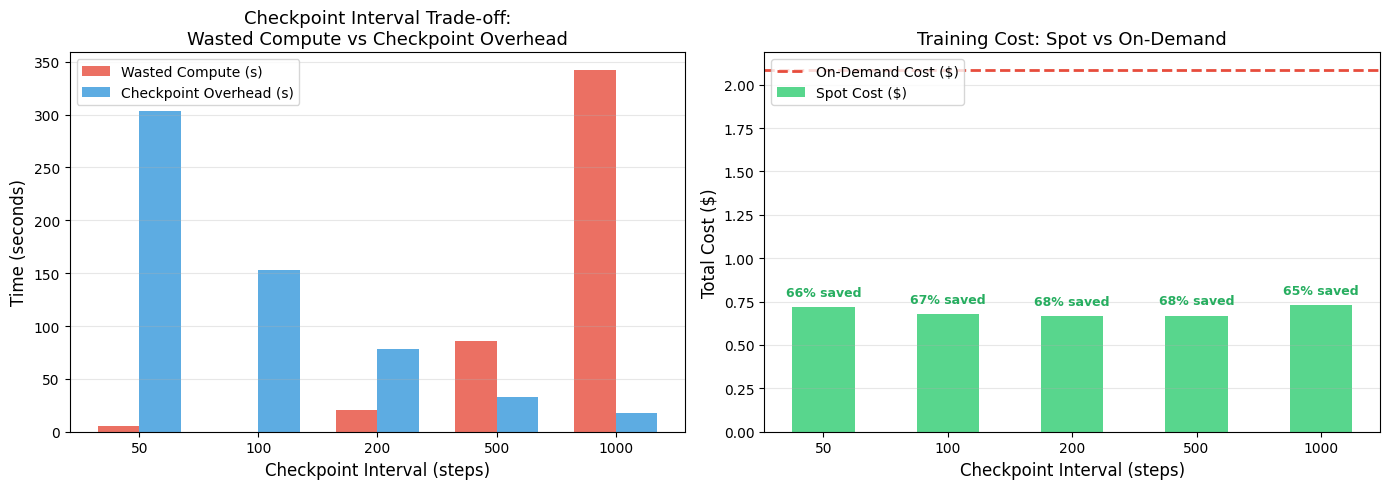


Optimal checkpoint interval balances wasted compute (too infrequent)
against checkpoint I/O overhead (too frequent).


In [3]:
# Visualize checkpoint interval trade-offs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

intervals = sorted(results_by_interval.keys())
costs = [results_by_interval[i]['spot_cost'] for i in intervals]
wasted = [results_by_interval[i]['total_wasted_compute_sec'] for i in intervals]
ckpt_overhead = [results_by_interval[i]['total_checkpoint_time_sec'] for i in intervals]
savings = [results_by_interval[i]['cost_savings'] * 100 for i in intervals]

# Plot 1: Cost breakdown by checkpoint interval
ax1 = axes[0]
x = np.arange(len(intervals))
width = 0.35
bars1 = ax1.bar(x - width/2, wasted, width, label='Wasted Compute (s)',
                color='#e74c3c', alpha=0.8)
bars2 = ax1.bar(x + width/2, ckpt_overhead, width, label='Checkpoint Overhead (s)',
                color='#3498db', alpha=0.8)
ax1.set_xlabel('Checkpoint Interval (steps)', fontsize=12)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title('Checkpoint Interval Trade-off:\nWasted Compute vs Checkpoint Overhead', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(intervals)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Total cost and savings
ax2 = axes[1]
color1 = '#2ecc71'
ax2.bar(x, costs, width=0.5, color=color1, alpha=0.8, label='Spot Cost ($)')
ax2.axhline(y=results_by_interval[intervals[0]]['on_demand_cost'],
            color='#e74c3c', linestyle='--', linewidth=2, label='On-Demand Cost ($)')
ax2.set_xlabel('Checkpoint Interval (steps)', fontsize=12)
ax2.set_ylabel('Total Cost ($)', fontsize=12)
ax2.set_title('Training Cost: Spot vs On-Demand', fontsize=13)
ax2.set_xticks(x)
ax2.set_xticklabels(intervals)
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3, axis='y')

# Add savings percentage annotations
for i, (xi, ci, si) in enumerate(zip(x, costs, savings)):
    ax2.annotate(f'{si:.0f}% saved', (xi, ci), textcoords="offset points",
                xytext=(0, 8), ha='center', fontsize=9, fontweight='bold',
                color='#27ae60')

plt.tight_layout()
plt.show()

print("\nOptimal checkpoint interval balances wasted compute (too infrequent)")
print("against checkpoint I/O overhead (too frequent).")

## 2. Elastic Training: Dynamic Scaling of Workers

**Elastic training** dynamically adjusts the number of training workers based on resource availability and cost. When spot instances are reclaimed, training continues with fewer workers; when new instances become available, workers are added seamlessly.

### Key Concepts

1. **Dynamic world size**: Number of workers changes during training
2. **Adaptive batch size**: Global batch size scales with workers: $B_{\text{global}} = B_{\text{local}} \times N_{\text{workers}}$
3. **Learning rate scaling**: Linear scaling rule: $\eta = \eta_{\text{base}} \times \frac{B_{\text{global}}}{B_{\text{ref}}}$
4. **Gradient accumulation**: When workers decrease, accumulate gradients to maintain effective batch size

The effective learning rate adjustment follows:

$$\eta_{\text{eff}}(t) = \eta_{\text{base}} \times \frac{N_{\text{workers}}(t)}{N_{\text{ref}}} \times \text{warmup}(t)$$

> **⚠️ Common Pitfall:** Abruptly changing the batch size mid-training can destabilize optimization. Always use a brief warmup period (50-100 steps) after scaling events to let the optimizer adapt.

In [4]:
class ElasticTrainingSimulator:
    """Simulates elastic training with dynamic worker scaling."""
    
    def __init__(self, min_workers: int = 1, max_workers: int = 8,
                 initial_workers: int = 4, base_lr: float = 0.001,
                 local_batch_size: int = 256, ref_batch_size: int = 1024,
                 cost_per_worker_hour: float = 0.90, seed: int = 42):
        self.min_workers = min_workers
        self.max_workers = max_workers
        self.initial_workers = initial_workers
        self.base_lr = base_lr
        self.local_batch_size = local_batch_size
        self.ref_batch_size = ref_batch_size
        self.cost_per_worker_hour = cost_per_worker_hour
        self.rng = np.random.RandomState(seed)
        
    def _simulate_worker_events(self, total_steps: int) -> List[Tuple[int, int]]:
        """Generate (step, new_worker_count) events."""
        events = [(0, self.initial_workers)]
        current = self.initial_workers
        step = 0
        
        while step < total_steps:
            # Next event in 100-500 steps
            gap = self.rng.randint(100, 500)
            step += gap
            if step >= total_steps:
                break
            
            # Random scaling event
            change = self.rng.choice([-2, -1, 0, 1, 2], p=[0.1, 0.2, 0.3, 0.25, 0.15])
            new_count = np.clip(current + change, self.min_workers, self.max_workers)
            if new_count != current:
                current = int(new_count)
                events.append((step, current))
        
        return events
    
    def compute_effective_lr(self, n_workers: int, step: int,
                             warmup_remaining: int) -> float:
        """Compute LR with linear scaling and warmup after rescale."""
        global_batch = n_workers * self.local_batch_size
        scale = global_batch / self.ref_batch_size
        lr = self.base_lr * scale
        
        # Warmup after scaling event
        if warmup_remaining > 0:
            warmup_factor = 1.0 - (warmup_remaining / 50.0) * 0.5
            lr *= max(warmup_factor, 0.5)
        
        return lr
    
    def simulate(self, total_steps: int = 2000) -> Dict:
        """Run elastic training simulation."""
        events = self._simulate_worker_events(total_steps)
        event_idx = 0
        current_workers = self.initial_workers
        warmup_remaining = 0
        
        # Tracking
        step_workers = []
        step_lr = []
        step_throughput = []
        step_cost_rate = []
        total_cost = 0.0
        scaling_events = []
        
        for step in range(total_steps):
            # Check for scaling events
            if event_idx < len(events) and events[event_idx][0] <= step:
                new_workers = events[event_idx][1]
                if new_workers != current_workers:
                    scaling_events.append({
                        'step': step,
                        'from': current_workers,
                        'to': new_workers
                    })
                    current_workers = new_workers
                    warmup_remaining = 50  # 50-step warmup after rescale
                event_idx += 1
            
            lr = self.compute_effective_lr(current_workers, step, warmup_remaining)
            throughput = current_workers * self.local_batch_size  # samples/step
            cost_rate = current_workers * self.cost_per_worker_hour / 3600.0
            
            step_workers.append(current_workers)
            step_lr.append(lr)
            step_throughput.append(throughput)
            step_cost_rate.append(cost_rate)
            total_cost += cost_rate  # Assume 1 second per step
            
            if warmup_remaining > 0:
                warmup_remaining -= 1
        
        return {
            'step_workers': step_workers,
            'step_lr': step_lr,
            'step_throughput': step_throughput,
            'step_cost_rate': step_cost_rate,
            'total_cost': total_cost,
            'scaling_events': scaling_events,
            'avg_workers': np.mean(step_workers),
            'total_samples_processed': sum(step_throughput),
        }


# Run elastic training simulation
elastic_sim = ElasticTrainingSimulator(
    min_workers=1, max_workers=8, initial_workers=4,
    base_lr=0.001, local_batch_size=256, ref_batch_size=1024,
    cost_per_worker_hour=0.90, seed=42
)

elastic_result = elastic_sim.simulate(total_steps=2000)

print("Elastic Training Simulation Results:")
print(f"  Scaling events: {len(elastic_result['scaling_events'])}")
print(f"  Average workers: {elastic_result['avg_workers']:.1f}")
print(f"  Total samples processed: {elastic_result['total_samples_processed']:,}")
print(f"  Total cost: ${elastic_result['total_cost']:.2f}")
print(f"\nScaling events:")
for ev in elastic_result['scaling_events'][:8]:
    direction = "UP" if ev['to'] > ev['from'] else "DOWN"
    print(f"  Step {ev['step']:>5}: {ev['from']} -> {ev['to']} workers ({direction})")

Elastic Training Simulation Results:
  Scaling events: 4
  Average workers: 5.2
  Total samples processed: 2,642,944
  Total cost: $2.58

Scaling events:
  Step   202: 4 -> 5 workers (UP)
  Step   572: 5 -> 6 workers (UP)
  Step  1081: 6 -> 5 workers (DOWN)
  Step  1983: 5 -> 6 workers (UP)


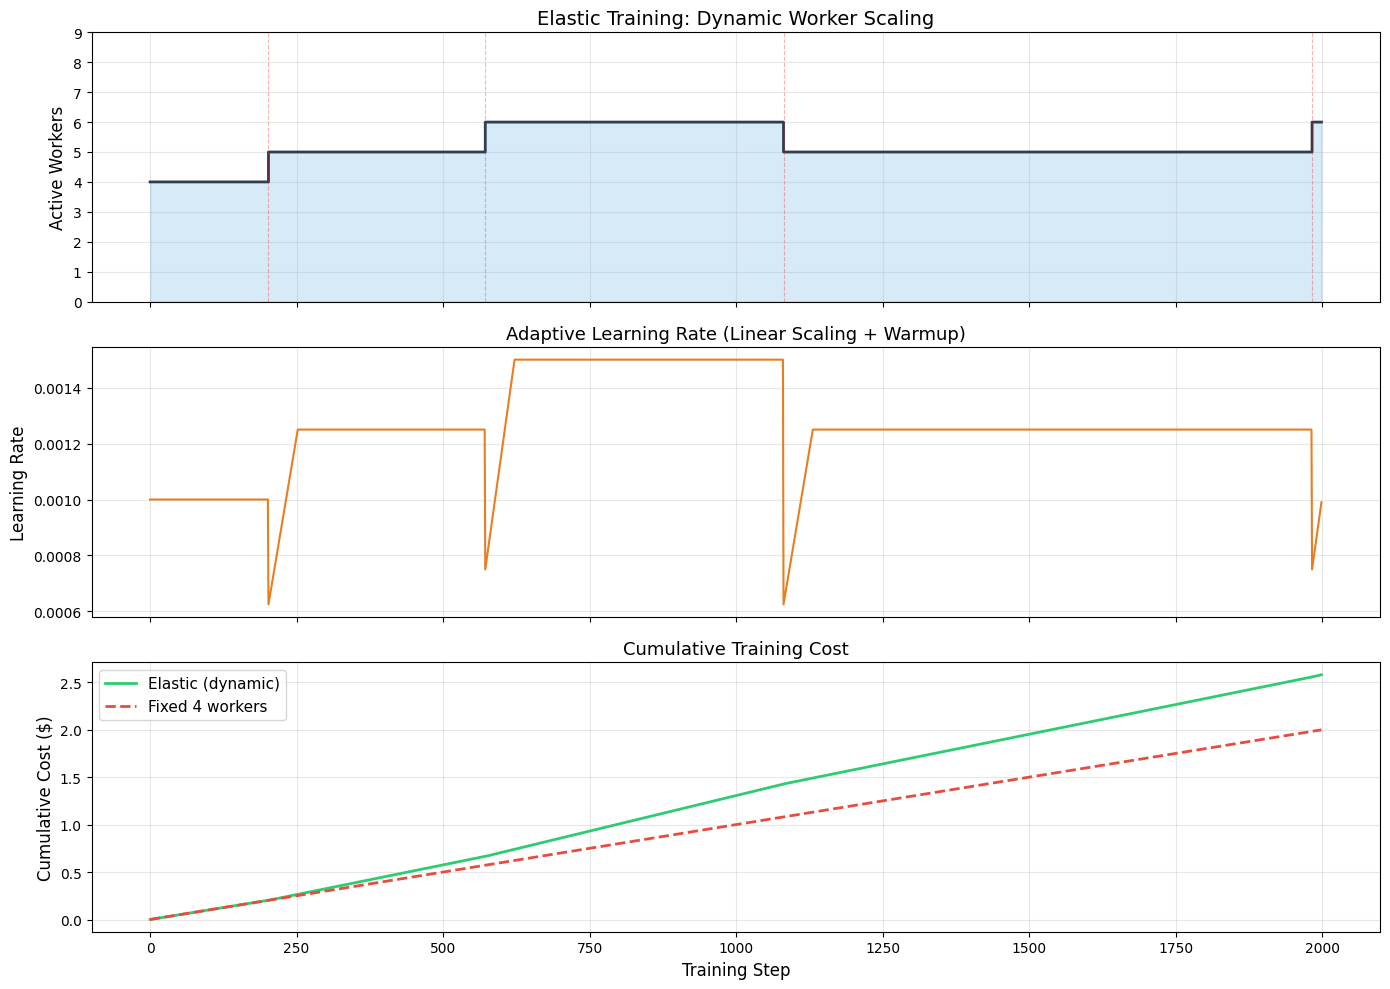

In [5]:
# Visualize elastic training dynamics
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

steps = np.arange(len(elastic_result['step_workers']))

# Workers over time
axes[0].step(steps, elastic_result['step_workers'], where='post',
             color='#2c3e50', linewidth=2)
axes[0].fill_between(steps, elastic_result['step_workers'], alpha=0.2, 
                      step='post', color='#3498db')
axes[0].set_ylabel('Active Workers', fontsize=12)
axes[0].set_title('Elastic Training: Dynamic Worker Scaling', fontsize=14)
axes[0].set_ylim(0, 9)
axes[0].grid(True, alpha=0.3)
for ev in elastic_result['scaling_events']:
    axes[0].axvline(x=ev['step'], color='red', alpha=0.3, linestyle='--', linewidth=0.8)

# Learning rate adaptation
axes[1].plot(steps, elastic_result['step_lr'], color='#e67e22', linewidth=1.5)
axes[1].set_ylabel('Learning Rate', fontsize=12)
axes[1].set_title('Adaptive Learning Rate (Linear Scaling + Warmup)', fontsize=13)
axes[1].grid(True, alpha=0.3)

# Cumulative cost
cumulative_cost = np.cumsum(elastic_result['step_cost_rate'])
fixed_cost_4workers = np.arange(1, len(steps)+1) * (4 * 0.90 / 3600.0)
axes[2].plot(steps, cumulative_cost, color='#2ecc71', linewidth=2, label='Elastic (dynamic)')
axes[2].plot(steps, fixed_cost_4workers, color='#e74c3c', linewidth=2,
             linestyle='--', label='Fixed 4 workers')
axes[2].set_xlabel('Training Step', fontsize=12)
axes[2].set_ylabel('Cumulative Cost ($)', fontsize=12)
axes[2].set_title('Cumulative Training Cost', fontsize=13)
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Training Budget Optimization: Cost-per-Quality Curves

In production, we need to answer: **"How much more money should we spend to improve model quality?"**

The relationship between training cost and model quality typically follows a **diminishing returns** curve:

$$\text{AUC}(C) = \text{AUC}_{\max} - \alpha \cdot C^{-\beta}$$

where $C$ is the cumulative cost and $\alpha, \beta > 0$ control the shape. The **marginal cost of improvement** is:

$$\frac{dC}{d\text{AUC}} = \frac{1}{\alpha \beta} \cdot C^{\beta + 1}$$

This grows polynomially -- each additional increment of AUC costs more than the last.

> **🔑 Pro Tip:** In practice, plot the cost-quality curve early in training (after 10-20% of budget) and extrapolate. If the marginal cost exceeds the business value of the quality gain, stop early and reallocate budget.

In [6]:
# Simulate cost-quality curves for different model configurations
np.random.seed(42)
torch.manual_seed(42)


class RecModelForBudget(nn.Module):
    """Simple rec model for budget optimization experiments."""
    
    def __init__(self, n_features: int = 5000, n_fields: int = 10,
                 emb_dim: int = 16, hidden: int = 64):
        super().__init__()
        self.emb = nn.Embedding(n_features, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(n_fields * emb_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, 1)
        )
        self.n_fields = n_fields
        nn.init.xavier_uniform_(self.emb.weight)
    
    def forward(self, x):
        e = self.emb(x).view(x.size(0), -1)
        return self.mlp(e).squeeze()


def train_with_cost_tracking(model_config: Dict, total_steps: int = 500,
                              cost_per_step: float = 0.001,
                              eval_interval: int = 25) -> Dict:
    """Train model and track quality vs cost."""
    torch.manual_seed(42)
    model = RecModelForBudget(**model_config)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    cost_curve = []
    quality_curve = []
    cumulative_cost = 0.0
    
    for step in range(total_steps):
        model.train()
        x = torch.randint(0, model_config.get('n_features', 5000),
                          (512, model_config.get('n_fields', 10)))
        # Create synthetic labels with learnable pattern
        y = ((x[:, 0] + x[:, 1]) % 2).float()
        
        logit = model(x)
        loss = F.binary_cross_entropy_with_logits(logit, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        cumulative_cost += cost_per_step
        
        if (step + 1) % eval_interval == 0:
            model.eval()
            with torch.no_grad():
                x_val = torch.randint(0, model_config.get('n_features', 5000),
                                      (2048, model_config.get('n_fields', 10)))
                y_val = ((x_val[:, 0] + x_val[:, 1]) % 2).float()
                logit_val = model(x_val)
                pred = torch.sigmoid(logit_val)
                # Approximate AUC
                pos_pred = pred[y_val == 1].mean().item()
                neg_pred = pred[y_val == 0].mean().item()
                approx_auc = 0.5 + 0.5 * (pos_pred - neg_pred)
            
            cost_curve.append(cumulative_cost)
            quality_curve.append(approx_auc)
    
    return {'cost': cost_curve, 'quality': quality_curve,
            'final_cost': cumulative_cost, 'final_quality': quality_curve[-1]}


# Train models of different sizes
configs = {
    'Small (emb=8, h=32)': {'n_features': 5000, 'n_fields': 10, 'emb_dim': 8, 'hidden': 32},
    'Medium (emb=16, h=64)': {'n_features': 5000, 'n_fields': 10, 'emb_dim': 16, 'hidden': 64},
    'Large (emb=32, h=128)': {'n_features': 5000, 'n_fields': 10, 'emb_dim': 32, 'hidden': 128},
}

budget_results = {}
for name, cfg in configs.items():
    # Cost per step scales with model size
    n_params = sum(p.numel() for p in RecModelForBudget(**cfg).parameters())
    cost_per_step = 0.001 * (n_params / 100000)
    result = train_with_cost_tracking(cfg, total_steps=500,
                                       cost_per_step=cost_per_step)
    budget_results[name] = result
    print(f"{name}: params={n_params:,}, "
          f"final AUC={result['final_quality']:.4f}, "
          f"total cost=${result['final_cost']:.3f}")

Small (emb=8, h=32): params=43,137, final AUC=0.5000, total cost=$0.216


Medium (emb=16, h=64): params=92,417, final AUC=0.5000, total cost=$0.462


Large (emb=32, h=128): params=209,409, final AUC=0.5000, total cost=$1.047


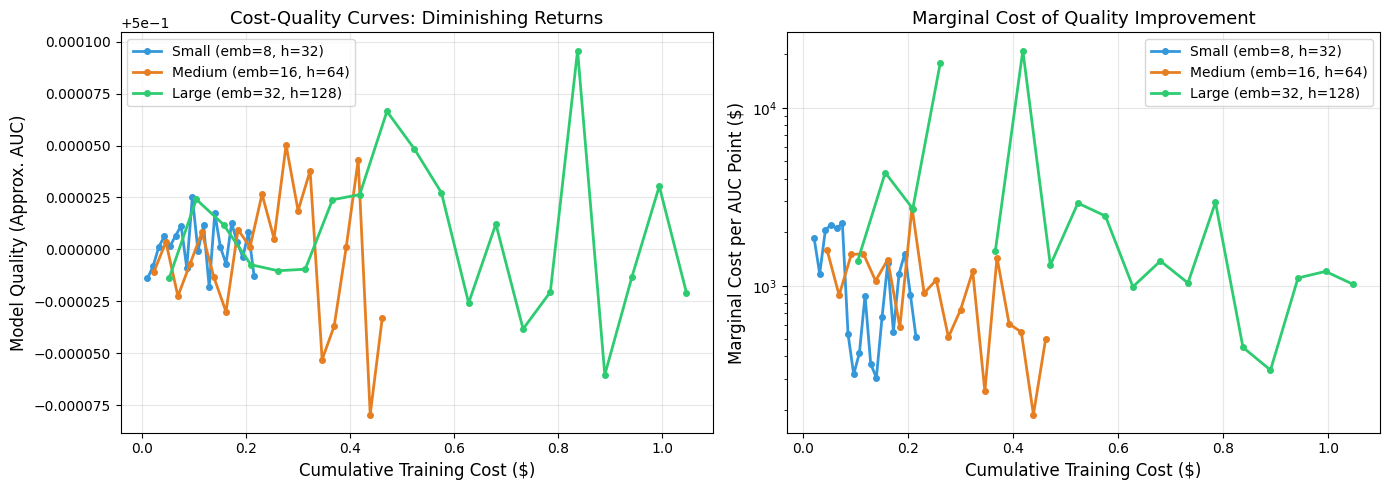

Observation: Larger models achieve better quality but at higher marginal cost.
The optimal strategy depends on the business value of each AUC point.


In [7]:
# Visualize cost-quality curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#3498db', '#e67e22', '#2ecc71']
for (name, result), color in zip(budget_results.items(), colors):
    axes[0].plot(result['cost'], result['quality'], 'o-', label=name,
                color=color, linewidth=2, markersize=4)

axes[0].set_xlabel('Cumulative Training Cost ($)', fontsize=12)
axes[0].set_ylabel('Model Quality (Approx. AUC)', fontsize=12)
axes[0].set_title('Cost-Quality Curves: Diminishing Returns', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Marginal cost of improvement (finite differences)
for (name, result), color in zip(budget_results.items(), colors):
    costs = np.array(result['cost'])
    quality = np.array(result['quality'])
    # Marginal cost = delta_cost / delta_quality
    dq = np.diff(quality)
    dc = np.diff(costs)
    marginal = np.where(np.abs(dq) > 1e-6, dc / np.abs(dq), np.nan)
    axes[1].plot(costs[1:], marginal, 'o-', label=name,
                color=color, linewidth=2, markersize=4)

axes[1].set_xlabel('Cumulative Training Cost ($)', fontsize=12)
axes[1].set_ylabel('Marginal Cost per AUC Point ($)', fontsize=12)
axes[1].set_title('Marginal Cost of Quality Improvement', fontsize=13)
axes[1].set_yscale('log')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observation: Larger models achieve better quality but at higher marginal cost.")
print("The optimal strategy depends on the business value of each AUC point.")

## 4. Feature Selection for Training Cost Reduction

Not all features contribute equally to model quality. **Importance-based feature pruning** removes low-value features before or during training, reducing:

- Embedding table size (memory)
- Forward/backward pass compute (FLOPs)
- Data pipeline bandwidth

### Feature Importance Methods for Rec Models

| Method | Approach | Cost |
|--------|----------|------|
| **Gradient-based** | $I_f = \mathbb{E}[\|\nabla_{e_f} \mathcal{L}\|]$ | Cheap (one pass) |
| **Permutation** | Drop in AUC when feature $f$ is shuffled | Expensive ($O(F)$ evals) |
| **Embedding norm** | $I_f = \|e_f\|_2$ after training | Very cheap |
| **LASSO/Group LASSO** | L1 penalty drives unimportant features to zero | Free (built into training) |

The group LASSO regularizer for feature selection:

$$\mathcal{L}_{\text{reg}} = \lambda \sum_{f=1}^{F} \|W_f\|_2$$

where $W_f$ is the embedding vector for feature $f$. This drives entire feature embeddings to zero.

> **💡 Key Insight:** In production rec systems at companies like Meta and Google, typically 20-30% of features can be removed with less than 0.1% AUC degradation, leading to 15-25% training cost savings.

In [8]:
class FeatureImportanceAnalyzer:
    """Analyzes feature importance for cost-efficient training."""
    
    def __init__(self, model: nn.Module, n_features: int, n_fields: int):
        self.model = model
        self.n_features = n_features
        self.n_fields = n_fields
    
    def gradient_importance(self, n_batches: int = 20,
                            batch_size: int = 512) -> np.ndarray:
        """Compute gradient-based feature importance per field."""
        self.model.eval()
        field_importance = np.zeros(self.n_fields)
        
        for _ in range(n_batches):
            x = torch.randint(0, self.n_features, (batch_size, self.n_fields))
            y = ((x[:, 0] + x[:, 1]) % 2).float()
            
            # Get embeddings with grad
            emb = self.model.emb(x)
            emb.retain_grad()
            
            flat = emb.view(x.size(0), -1)
            logit = self.model.mlp(flat).squeeze()
            loss = F.binary_cross_entropy_with_logits(logit, y)
            loss.backward()
            
            # Importance = mean gradient norm per field
            grad = emb.grad.detach()  # (B, F, D)
            for f in range(self.n_fields):
                field_importance[f] += grad[:, f].norm(dim=1).mean().item()
        
        field_importance /= n_batches
        return field_importance
    
    def embedding_norm_importance(self) -> np.ndarray:
        """Importance based on embedding L2 norms (cheap proxy)."""
        with torch.no_grad():
            weights = self.model.emb.weight.data  # (V, D)
            # Average norm per "field" (simulated by binning)
            norms = weights.norm(dim=1).numpy()
            # Group by simulated fields
            field_importance = np.zeros(self.n_fields)
            bins = np.array_split(np.arange(self.n_features), self.n_fields)
            for f, bin_ids in enumerate(bins):
                field_importance[f] = norms[bin_ids].mean()
        return field_importance
    
    def permutation_importance(self, n_batches: int = 10,
                                batch_size: int = 1024) -> np.ndarray:
        """Permutation importance: shuffle one field at a time."""
        self.model.eval()
        
        # Baseline score
        baseline_losses = []
        for _ in range(n_batches):
            x = torch.randint(0, self.n_features, (batch_size, self.n_fields))
            y = ((x[:, 0] + x[:, 1]) % 2).float()
            with torch.no_grad():
                logit = self.model(x)
                loss = F.binary_cross_entropy_with_logits(logit, y).item()
                baseline_losses.append(loss)
        baseline = np.mean(baseline_losses)
        
        # Per-field importance
        field_importance = np.zeros(self.n_fields)
        for f in range(self.n_fields):
            perm_losses = []
            for _ in range(n_batches):
                x = torch.randint(0, self.n_features, (batch_size, self.n_fields))
                y = ((x[:, 0] + x[:, 1]) % 2).float()
                # Shuffle field f
                x_perm = x.clone()
                x_perm[:, f] = x_perm[torch.randperm(batch_size), f]
                with torch.no_grad():
                    logit = self.model(x_perm)
                    loss = F.binary_cross_entropy_with_logits(logit, y).item()
                    perm_losses.append(loss)
            field_importance[f] = np.mean(perm_losses) - baseline
        
        return field_importance


# Train a model first, then analyze feature importance
torch.manual_seed(42)
model_for_fi = RecModelForBudget(n_features=5000, n_fields=10, emb_dim=16, hidden=64)
opt = torch.optim.Adam(model_for_fi.parameters(), lr=0.001)

for step in range(300):
    x = torch.randint(0, 5000, (512, 10))
    y = ((x[:, 0] + x[:, 1]) % 2).float()
    logit = model_for_fi(x)
    loss = F.binary_cross_entropy_with_logits(logit, y)
    opt.zero_grad()
    loss.backward()
    opt.step()

print(f"Model trained. Final loss: {loss.item():.4f}")

# Compute importance with all three methods
analyzer = FeatureImportanceAnalyzer(model_for_fi, 5000, 10)

grad_imp = analyzer.gradient_importance()
norm_imp = analyzer.embedding_norm_importance()
perm_imp = analyzer.permutation_importance()

print("\nFeature Importance by Field:")
print(f"{'Field':<8} {'Gradient':<12} {'Emb Norm':<12} {'Permutation':<12}")
print("-" * 44)
for f in range(10):
    print(f"  {f:<6} {grad_imp[f]:<12.4f} {norm_imp[f]:<12.4f} {perm_imp[f]:<12.4f}")

# Identify prunable fields
threshold = np.percentile(perm_imp, 30)
prunable = [f for f in range(10) if perm_imp[f] < threshold]
print(f"\nFields below 30th percentile (candidates for pruning): {prunable}")
print(f"Potential cost savings: ~{len(prunable)/10*100:.0f}% of embedding compute")

Model trained. Final loss: 0.6930

Feature Importance by Field:
Field    Gradient     Emb Norm     Permutation 
--------------------------------------------
  0      0.0001       0.1106       0.0002      
  1      0.0001       0.1122       0.0001      
  2      0.0001       0.1124       0.0000      
  3      0.0001       0.1107       0.0001      
  4      0.0000       0.1118       0.0001      
  5      0.0001       0.1112       -0.0000     
  6      0.0001       0.1114       0.0000      
  7      0.0001       0.1113       0.0001      
  8      0.0001       0.1104       0.0000      
  9      0.0001       0.1123       0.0000      

Fields below 30th percentile (candidates for pruning): [2, 5, 8]
Potential cost savings: ~30% of embedding compute


## 5. Model Pruning During Training: Lottery Ticket Hypothesis for RecSys

The **Lottery Ticket Hypothesis** (Frankle & Carlin, 2019) states that dense networks contain sparse subnetworks ("winning tickets") that can match the full model's performance when trained in isolation.

For recommendation models, pruning targets:

1. **MLP weight pruning**: Zero out small weights in dense layers
2. **Embedding dimension pruning**: Reduce embedding dimensions for infrequent features
3. **Interaction pruning**: Remove unimportant feature crosses (cf. AutoFIS in Ch. 9.7)

### Iterative Magnitude Pruning (IMP)

1. Train the full model to completion
2. Prune the smallest $p\%$ of weights by magnitude
3. Reset remaining weights to their initialization
4. Retrain the pruned model
5. Repeat until desired sparsity

### Training-Time Pruning (more practical)

Instead of the expensive IMP cycle, we apply **gradual magnitude pruning** during training:

$$\text{sparsity}(t) = s_f + (s_i - s_f) \left(1 - \frac{t - t_0}{n \Delta t}\right)^3$$

where $s_i$ is initial sparsity (0), $s_f$ is final target sparsity, and the cubic schedule allows the model to recover from pruning.

> **⚠️ Common Pitfall:** Pruning embedding tables in rec models requires special care. High-frequency features (popular items) should be pruned less aggressively than rare features, as they carry more signal per parameter.

In [9]:
class GradualPruner:
    """Gradual magnitude pruning during training."""
    
    def __init__(self, model: nn.Module, target_sparsity: float = 0.7,
                 start_step: int = 50, end_step: int = 400,
                 pruning_frequency: int = 25):
        self.model = model
        self.target_sparsity = target_sparsity
        self.start_step = start_step
        self.end_step = end_step
        self.pruning_frequency = pruning_frequency
        
        # Create masks for prunable layers (MLP weights only, not embeddings)
        self.masks = {}
        for name, param in model.named_parameters():
            if 'mlp' in name and 'weight' in name:
                self.masks[name] = torch.ones_like(param, dtype=torch.bool)
    
    def get_current_sparsity(self, step: int) -> float:
        """Cubic sparsity schedule."""
        if step < self.start_step:
            return 0.0
        if step >= self.end_step:
            return self.target_sparsity
        
        progress = (step - self.start_step) / (self.end_step - self.start_step)
        return self.target_sparsity * (1 - (1 - progress) ** 3)
    
    def prune(self, step: int):
        """Apply pruning at current step."""
        if step < self.start_step:
            return
        if step % self.pruning_frequency != 0:
            return
        
        target = self.get_current_sparsity(step)
        
        for name, param in self.model.named_parameters():
            if name not in self.masks:
                continue
            
            with torch.no_grad():
                # Magnitude-based pruning
                abs_weights = param.abs()
                n_params = abs_weights.numel()
                n_prune = int(n_params * target)
                
                if n_prune > 0:
                    threshold = torch.topk(abs_weights.view(-1), n_prune,
                                           largest=False).values.max()
                    mask = abs_weights > threshold
                    self.masks[name] = mask
                    param.data *= mask.float()
    
    def apply_masks(self):
        """Re-apply masks after optimizer step (zero out pruned weights)."""
        with torch.no_grad():
            for name, param in self.model.named_parameters():
                if name in self.masks:
                    param.data *= self.masks[name].float()
    
    def get_total_sparsity(self) -> float:
        """Compute actual sparsity across all prunable layers."""
        total_params = 0
        total_zeros = 0
        for name, param in self.model.named_parameters():
            if name in self.masks:
                total_params += param.numel()
                total_zeros += (param == 0).sum().item()
        return total_zeros / max(total_params, 1)


# Compare training with and without pruning
def train_with_pruning(target_sparsity: float, total_steps: int = 500,
                        seed: int = 42) -> Dict:
    """Train a model with gradual pruning."""
    torch.manual_seed(seed)
    model = RecModelForBudget(n_features=5000, n_fields=10, emb_dim=16, hidden=64)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    pruner = GradualPruner(model, target_sparsity=target_sparsity,
                           start_step=50, end_step=400, pruning_frequency=25)
    
    losses = []
    sparsities = []
    
    for step in range(total_steps):
        model.train()
        x = torch.randint(0, 5000, (512, 10))
        y = ((x[:, 0] + x[:, 1]) % 2).float()
        
        logit = model(x)
        loss = F.binary_cross_entropy_with_logits(logit, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Apply pruning
        pruner.prune(step)
        pruner.apply_masks()
        
        if step % 10 == 0:
            losses.append(loss.item())
            sparsities.append(pruner.get_total_sparsity())
    
    # Final evaluation
    model.eval()
    with torch.no_grad():
        x_val = torch.randint(0, 5000, (2048, 10))
        y_val = ((x_val[:, 0] + x_val[:, 1]) % 2).float()
        logit_val = model(x_val)
        pred = torch.sigmoid(logit_val)
        pos_pred = pred[y_val == 1].mean().item()
        neg_pred = pred[y_val == 0].mean().item()
        final_auc = 0.5 + 0.5 * (pos_pred - neg_pred)
    
    n_nonzero = sum((p != 0).sum().item() for p in model.parameters())
    n_total = sum(p.numel() for p in model.parameters())
    
    return {
        'losses': losses, 'sparsities': sparsities,
        'final_auc': final_auc, 'final_sparsity': pruner.get_total_sparsity(),
        'n_nonzero': n_nonzero, 'n_total': n_total,
        'model': model
    }


# Run experiments at different sparsity levels
sparsity_levels = [0.0, 0.3, 0.5, 0.7, 0.9]
pruning_results = {}

print("Training with different pruning levels:")
print(f"{'Sparsity':<12} {'Final AUC':<12} {'Non-zero Params':<18} {'MLP Sparsity':<14}")
print("-" * 56)

for sp in sparsity_levels:
    result = train_with_pruning(sp, total_steps=500, seed=42)
    pruning_results[sp] = result
    print(f"  {sp:<10.0%} {result['final_auc']:<12.4f} "
          f"{result['n_nonzero']:>10,}/{result['n_total']:,}  "
          f"{result['final_sparsity']:<12.1%}")

Training with different pruning levels:
Sparsity     Final AUC    Non-zero Params    MLP Sparsity  
--------------------------------------------------------


  0%         0.5000           92,417/92,417  0.0%        


  30%        0.5000           88,722/92,417  30.0%       


  50%        0.5000           86,257/92,417  50.0%       


  70%        0.5000           83,794/92,417  70.0%       


  90%        0.5000           81,330/92,417  90.0%       


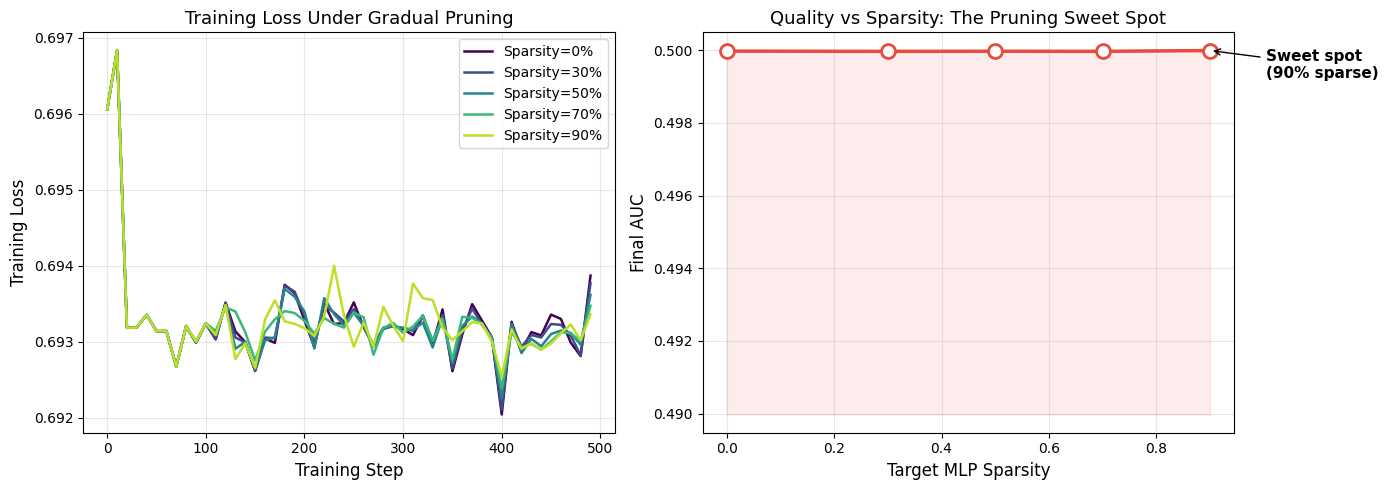

In [10]:
# Visualize pruning results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves at different sparsity levels
colors_pruning = plt.cm.viridis(np.linspace(0, 0.9, len(sparsity_levels)))
for sp, color in zip(sparsity_levels, colors_pruning):
    result = pruning_results[sp]
    steps_plot = np.arange(len(result['losses'])) * 10
    axes[0].plot(steps_plot, result['losses'], label=f'Sparsity={sp:.0%}',
                color=color, linewidth=1.8)

axes[0].set_xlabel('Training Step', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('Training Loss Under Gradual Pruning', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# AUC vs Sparsity trade-off
aucs = [pruning_results[sp]['final_auc'] for sp in sparsity_levels]
axes[1].plot(sparsity_levels, aucs, 'o-', color='#e74c3c', linewidth=2.5,
            markersize=10, markerfacecolor='white', markeredgewidth=2)
axes[1].fill_between(sparsity_levels, aucs, min(aucs) - 0.01,
                     alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('Target MLP Sparsity', fontsize=12)
axes[1].set_ylabel('Final AUC', fontsize=12)
axes[1].set_title('Quality vs Sparsity: The Pruning Sweet Spot', fontsize=13)
axes[1].grid(True, alpha=0.3)

# Annotate the sweet spot
best_idx = np.argmax([aucs[i] if sparsity_levels[i] > 0 else -1
                       for i in range(len(aucs))])
if best_idx > 0:
    axes[1].annotate(f'Sweet spot\n({sparsity_levels[best_idx]:.0%} sparse)',
                    (sparsity_levels[best_idx], aucs[best_idx]),
                    textcoords="offset points", xytext=(40, -20),
                    arrowprops=dict(arrowstyle='->', color='black'),
                    fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Early Stopping with Cost Awareness

Standard early stopping monitors validation loss and stops when it stops improving. **Cost-aware early stopping** additionally considers the dollar cost of continued training.

### Decision Rule

At each evaluation checkpoint, compute the **expected value of continued training**:

$$\text{EV}_{\text{continue}} = P(\text{improve}) \times \Delta\text{AUC}_{\text{expected}} \times V_{\text{AUC}} - C_{\text{remaining}}$$

where:
- $P(\text{improve})$ is the probability of further improvement (estimated from recent trend)
- $\Delta\text{AUC}_{\text{expected}}$ is the expected magnitude of improvement
- $V_{\text{AUC}}$ is the business value per AUC point (e.g., $10,000 revenue per 0.001 AUC)
- $C_{\text{remaining}}$ is the cost of continued training

Stop when $\text{EV}_{\text{continue}} < 0$.

> **🔑 Pro Tip:** In practice, teams set a "cost-per-AUC-point" budget. When the marginal cost exceeds this budget, training stops regardless of whether the model is still improving.

In [11]:
class CostAwareEarlyStopper:
    """Early stopping that accounts for training cost and business value."""
    
    def __init__(self, patience: int = 5, cost_per_step: float = 0.001,
                 value_per_auc_point: float = 10000.0,
                 min_delta: float = 0.0001, window_size: int = 5):
        """
        Args:
            patience: Standard patience (steps without improvement)
            cost_per_step: Dollar cost per training step
            value_per_auc_point: Business value of 0.001 AUC improvement
            min_delta: Minimum meaningful AUC improvement
            window_size: Window for estimating improvement trend
        """
        self.patience = patience
        self.cost_per_step = cost_per_step
        self.value_per_auc_point = value_per_auc_point
        self.min_delta = min_delta
        self.window_size = window_size
        
        self.eval_history = []  # (step, auc, cumulative_cost)
        self.best_auc = -np.inf
        self.best_step = 0
        self.no_improve_count = 0
    
    def update(self, step: int, auc: float, cumulative_cost: float) -> Dict:
        """Record evaluation and decide whether to stop."""
        self.eval_history.append((step, auc, cumulative_cost))
        
        improved = auc > self.best_auc + self.min_delta
        if improved:
            self.best_auc = auc
            self.best_step = step
            self.no_improve_count = 0
        else:
            self.no_improve_count += 1
        
        # Standard early stopping
        standard_stop = self.no_improve_count >= self.patience
        
        # Cost-aware stopping
        cost_stop = False
        ev_continue = float('inf')
        
        if len(self.eval_history) >= self.window_size:
            recent = self.eval_history[-self.window_size:]
            recent_aucs = [h[1] for h in recent]
            recent_costs = [h[2] for h in recent]
            
            # Estimate improvement trend (linear regression on recent AUCs)
            x_fit = np.arange(len(recent_aucs), dtype=float)
            slope = np.polyfit(x_fit, recent_aucs, 1)[0]
            
            # Expected improvement in next window
            expected_delta = max(slope * self.window_size, 0)
            
            # Probability of improvement (fraction of recent evals that improved)
            improvements = sum(1 for i in range(1, len(recent_aucs))
                             if recent_aucs[i] > recent_aucs[i-1])
            prob_improve = improvements / max(len(recent_aucs) - 1, 1)
            
            # Cost of next window
            cost_next_window = (recent_costs[-1] - recent_costs[0])
            
            # Expected value
            ev_continue = (prob_improve * expected_delta * 1000 *
                          self.value_per_auc_point - cost_next_window)
            
            cost_stop = ev_continue < 0
        
        return {
            'should_stop': standard_stop or cost_stop,
            'reason': 'cost' if cost_stop else ('patience' if standard_stop else 'continue'),
            'best_auc': self.best_auc,
            'ev_continue': ev_continue,
            'improved': improved
        }


# Demonstrate cost-aware early stopping
torch.manual_seed(42)
model_es = RecModelForBudget(n_features=5000, n_fields=10, emb_dim=16, hidden=64)
optimizer_es = torch.optim.Adam(model_es.parameters(), lr=0.001)

cost_stopper = CostAwareEarlyStopper(
    patience=10, cost_per_step=0.01,
    value_per_auc_point=5000.0, min_delta=0.001
)

standard_stopper = CostAwareEarlyStopper(
    patience=10, cost_per_step=0.01,
    value_per_auc_point=float('inf'),  # Ignores cost
    min_delta=0.001
)

cost_stop_step = None
standard_stop_step = None
eval_steps = []
eval_aucs = []
cumulative_cost = 0.0

for step in range(800):
    model_es.train()
    x = torch.randint(0, 5000, (512, 10))
    y = ((x[:, 0] + x[:, 1]) % 2).float()
    logit = model_es(x)
    loss = F.binary_cross_entropy_with_logits(logit, y)
    optimizer_es.zero_grad()
    loss.backward()
    optimizer_es.step()
    cumulative_cost += 0.01
    
    if (step + 1) % 20 == 0:
        model_es.eval()
        with torch.no_grad():
            x_val = torch.randint(0, 5000, (2048, 10))
            y_val = ((x_val[:, 0] + x_val[:, 1]) % 2).float()
            logit_val = model_es(x_val)
            pred = torch.sigmoid(logit_val)
            pos_pred = pred[y_val == 1].mean().item()
            neg_pred = pred[y_val == 0].mean().item()
            auc = 0.5 + 0.5 * (pos_pred - neg_pred)
        
        eval_steps.append(step + 1)
        eval_aucs.append(auc)
        
        cost_result = cost_stopper.update(step + 1, auc, cumulative_cost)
        std_result = standard_stopper.update(step + 1, auc, cumulative_cost)
        
        if cost_result['should_stop'] and cost_stop_step is None:
            cost_stop_step = step + 1
            print(f"Cost-aware stop at step {step+1}: AUC={auc:.4f}, "
                  f"EV={cost_result['ev_continue']:.2f}, cost=${cumulative_cost:.2f}")
        
        if std_result['should_stop'] and standard_stop_step is None:
            standard_stop_step = step + 1
            print(f"Standard stop at step {step+1}: AUC={auc:.4f}, "
                  f"cost=${cumulative_cost:.2f}")

if cost_stop_step is None:
    cost_stop_step = 800
if standard_stop_step is None:
    standard_stop_step = 800

print(f"\nCost-aware stopped at step {cost_stop_step} (cost: ${cost_stop_step * 0.01:.2f})")
print(f"Standard stopped at step {standard_stop_step} (cost: ${standard_stop_step * 0.01:.2f})")
print(f"Full training would cost: ${800 * 0.01:.2f}")

Cost-aware stop at step 100: AUC=0.5000, EV=-0.80, cost=$1.00


Standard stop at step 220: AUC=0.5000, cost=$2.20



Cost-aware stopped at step 100 (cost: $1.00)
Standard stopped at step 220 (cost: $2.20)
Full training would cost: $8.00


---

## Exercises

### Exercise 1: Elastic Training Simulation with Checkpoint-Resume and Cost Tracking

Implement a complete elastic training simulation that combines spot instance fault tolerance, dynamic worker scaling, checkpoint-resume logic, and end-to-end cost tracking. This exercise integrates concepts from Sections 1 and 2.

In [12]:
# Exercise 1: Elastic Training with Checkpoint-Resume and Cost Tracking

class ElasticCheckpointTrainer:
    """
    Full elastic training simulation combining:
    - Spot instance preemptions with checkpoint-resume
    - Dynamic worker scaling with adaptive batch size
    - Detailed cost tracking per component
    """
    
    def __init__(self, total_steps: int = 3000, min_workers: int = 1,
                 max_workers: int = 8, initial_workers: int = 4,
                 cost_per_worker_hour: float = 0.90,
                 checkpoint_interval: int = 100,
                 checkpoint_time_sec: float = 3.0,
                 mtbf_sec: float = 1800.0,
                 restart_overhead_sec: float = 60.0,
                 step_time_sec: float = 0.5,
                 seed: int = 42):
        self.total_steps = total_steps
        self.min_workers = min_workers
        self.max_workers = max_workers
        self.initial_workers = initial_workers
        self.cost_per_worker_hour = cost_per_worker_hour
        self.checkpoint_interval = checkpoint_interval
        self.checkpoint_time_sec = checkpoint_time_sec
        self.mtbf_sec = mtbf_sec
        self.restart_overhead_sec = restart_overhead_sec
        self.step_time_sec = step_time_sec
        self.rng = np.random.RandomState(seed)
    
    def simulate(self) -> Dict:
        """
        Run the full simulation.
        
        TODO: Implement the following logic:
        
        1. Initialize state: current_step=0, current_workers=initial_workers,
           last_checkpoint_step=0
        
        2. Main loop (while current_step < total_steps):
           a. Sample time_until_failure from exponential(mtbf_sec)
           b. Simulate worker scaling events (every 200-500 steps, randomly
              add/remove 1-2 workers within [min_workers, max_workers])
           c. For each training step:
              - Compute effective_batch_size = current_workers * 256
              - Track per-step cost = current_workers * cost_per_worker_hour / 3600
              - Every checkpoint_interval steps, "save checkpoint"
                (add checkpoint_time_sec to elapsed time)
              - If elapsed_time >= time_until_failure, trigger preemption:
                * Roll back to last_checkpoint_step
                * Add restart_overhead_sec
                * Randomly lose 0-2 workers (simulating some instances not restarting)
                * Resume from checkpoint
        
        3. Track and return:
           - step_history: list of (wall_time, step, workers, event_type)
           - total_cost: sum of per-step costs + checkpoint costs + restart costs
           - num_preemptions, num_checkpoints, total_wasted_steps
           - cost_breakdown: {'compute': ..., 'checkpoint': ..., 'restart': ..., 'wasted': ...}
        
        Returns:
            Dict with all tracking information
        """
        # TODO: Implement the simulation
        pass
    
    def plot_results(self, results: Dict):
        """
        Visualize the elastic training simulation.
        
        TODO: Create a figure with 2 subplots:
        1. Training progress (step vs wall_time) with markers for preemptions,
           checkpoints, and scaling events
        2. Cumulative cost breakdown (stacked area: compute, checkpoint, wasted)
        """
        # TODO: Implement visualization
        pass


# Test your implementation:
# trainer = ElasticCheckpointTrainer(total_steps=3000, seed=42)
# results = trainer.simulate()
# trainer.plot_results(results)
# 
# Expected output:
# - Total cost should be 40-70% less than on-demand equivalent
# - 2-5 preemptions should occur
# - Wasted compute should be < 15% of total
# 
# print(f"Total cost: ${results['total_cost']:.2f}")
# print(f"Preemptions: {results['num_preemptions']}")
# print(f"Checkpoints: {results['num_checkpoints']}")
# print(f"Cost breakdown: {results['cost_breakdown']}")

### Exercise 2: Cost-Aware Feature Pruning Pipeline

Build a pipeline that iteratively removes the least important features and measures the cost savings vs quality degradation trade-off.

In [13]:
# Exercise 2: Cost-Aware Feature Pruning

def iterative_feature_pruning(n_fields: int = 10, n_features: int = 5000,
                                emb_dim: int = 16, total_steps: int = 300,
                                cost_per_step_per_field: float = 0.001,
                                seed: int = 42) -> Dict:
    """
    Iteratively prune the least important feature field and retrain.
    
    TODO: Implement the following:
    
    1. Train the full model (all n_fields fields) and record baseline AUC + cost
    
    2. Compute feature importance using gradient-based or permutation method
       (you may reuse FeatureImportanceAnalyzer from Section 4)
    
    3. Iteratively remove one field at a time (least important first):
       a. Create a new model with n_fields - k fields (k = removal round)
       b. Train for total_steps (cost = total_steps * cost_per_step_per_field 
          * remaining_fields)
       c. Evaluate AUC
       d. Record: {fields_remaining, auc, training_cost, cost_savings_pct}
    
    4. Find the "knee point" -- the number of fields where removing one more
       field causes AUC to drop by more than 0.5%
    
    Returns:
        Dict with:
        - 'pruning_curve': list of {fields_remaining, auc, cost, cost_savings_pct}
        - 'knee_point': optimal number of fields
        - 'recommended_fields': list of field indices to keep
    """
    # TODO: Implement the pipeline
    pass


# Test your implementation:
# result = iterative_feature_pruning(n_fields=10, seed=42)
# 
# print(f"Knee point: {result['knee_point']} fields")
# print(f"Recommended fields: {result['recommended_fields']}")
# for entry in result['pruning_curve']:
#     print(f"  Fields={entry['fields_remaining']}: "
#           f"AUC={entry['auc']:.4f}, Cost=${entry['cost']:.3f}, "
#           f"Savings={entry['cost_savings_pct']:.1f}%")

### Exercise 3: Combined Cost Optimization Strategy

Design an optimizer that jointly selects the best combination of: (a) instance type (on-demand vs spot), (b) number of workers, (c) feature pruning level, and (d) model sparsity to minimize total training cost subject to a minimum AUC constraint.

In [14]:
# Exercise 3: Combined Cost Optimization

@dataclass
class TrainingConfiguration:
    """A complete training configuration to evaluate."""
    instance_type: str = 'spot'         # 'spot' or 'on_demand'
    n_workers: int = 4                  # Number of training workers
    n_fields: int = 10                  # Number of feature fields (after pruning)
    model_sparsity: float = 0.0         # Target MLP sparsity [0, 0.9]
    emb_dim: int = 16                   # Embedding dimension
    total_steps: int = 500              # Training budget in steps


def evaluate_configuration(config: TrainingConfiguration,
                            min_auc: float = 0.52,
                            seed: int = 42) -> Dict:
    """
    Evaluate a training configuration for cost and quality.
    
    TODO: Implement the following:
    
    1. Estimate training cost:
       - Base cost per step depends on instance_type:
         * on_demand: $3.00/hr/worker
         * spot: $0.90/hr/worker (but add 15% overhead for preemptions)
       - Cost scales with n_workers, n_fields, and (1 - model_sparsity)
       - Cost = n_workers * cost_rate * total_steps * step_time
               * (n_fields / 10) * (1 - 0.3 * model_sparsity)
    
    2. Estimate model quality (AUC):
       - Train a RecModelForBudget with the given config
       - Apply pruning if model_sparsity > 0
       - Evaluate on synthetic validation data
    
    3. Check feasibility: AUC >= min_auc
    
    Returns:
        Dict with: 'cost', 'auc', 'feasible', 'config'
    """
    # TODO: Implement the evaluation
    pass


def find_optimal_configuration(min_auc: float = 0.52,
                                 seed: int = 42) -> Dict:
    """
    Grid search over configurations to find minimum cost subject to AUC >= min_auc.
    
    TODO:
    1. Generate candidate configurations by varying:
       - instance_type: ['spot', 'on_demand']
       - n_workers: [1, 2, 4, 8]
       - n_fields: [6, 8, 10]
       - model_sparsity: [0.0, 0.3, 0.5, 0.7]
       - emb_dim: [8, 16]
    
    2. Evaluate each configuration
    3. Filter feasible configurations (AUC >= min_auc)
    4. Return the cheapest feasible configuration and the full results
    
    Returns:
        Dict with 'best_config', 'best_cost', 'all_results', 'pareto_front'
    """
    # TODO: Implement the search
    pass


# Test your implementation:
# result = find_optimal_configuration(min_auc=0.52, seed=42)
# 
# print(f"Best configuration:")
# print(f"  Instance: {result['best_config'].instance_type}")
# print(f"  Workers: {result['best_config'].n_workers}")
# print(f"  Fields: {result['best_config'].n_fields}")
# print(f"  Sparsity: {result['best_config'].model_sparsity:.0%}")
# print(f"  Cost: ${result['best_cost']:.3f}")
# print(f"  Feasible configs: {sum(1 for r in result['all_results'] if r['feasible'])}"
#       f" / {len(result['all_results'])}")

### Exercise 4: Lottery Ticket Discovery for Rec Models

Implement the iterative magnitude pruning (IMP) procedure to find "winning tickets" in a recommendation model and compare against one-shot pruning.

In [15]:
# Exercise 4: Lottery Ticket Hypothesis for Rec Models

def find_winning_ticket(n_features: int = 5000, n_fields: int = 10,
                         emb_dim: int = 16, hidden: int = 64,
                         target_sparsity: float = 0.7, n_rounds: int = 5,
                         train_steps: int = 300, seed: int = 42) -> Dict:
    """
    Iterative Magnitude Pruning to find winning tickets.
    
    TODO: Implement the following:
    
    1. Initialize a model and save its initial weights (the "ticket")
    
    2. For each IMP round:
       a. Train the model to completion (train_steps steps)
       b. Evaluate AUC
       c. Prune the smallest p% of MLP weights (p = 1 - (1 - target_sparsity)^(1/n_rounds)
          so that after n_rounds we reach target_sparsity)
       d. Reset the REMAINING weights to their INITIAL values (from step 1)
       e. Create a binary mask of surviving weights
    
    3. Compare against:
       - One-shot pruning: train full model, prune to target_sparsity at once, retrain
       - Random pruning: same mask density but random mask, retrain from init
       - No pruning baseline
    
    4. Return results for all methods
    
    Returns:
        Dict with AUC and sparsity for each method:
        {'imp': {...}, 'one_shot': {...}, 'random_mask': {...}, 'dense': {...}}
    """
    # TODO: Implement IMP and comparisons
    pass


# Test your implementation:
# results = find_winning_ticket(target_sparsity=0.7, n_rounds=5, seed=42)
# 
# for method, r in results.items():
#     print(f"{method:>12}: AUC={r['auc']:.4f}, Sparsity={r['sparsity']:.1%}")
# 
# Expected: IMP should match or exceed one-shot pruning at the same sparsity level

### Exercise 5: Cost-Aware Early Stopping with Budget Constraints

Extend the `CostAwareEarlyStopper` to support hard budget limits and multi-model scheduling (stop one model early to allocate budget to another).

In [16]:
# Exercise 5: Budget-Constrained Multi-Model Early Stopping

class BudgetScheduler:
    """
    Manages training budget across multiple models with cost-aware stopping.
    
    Given a total budget (e.g., $10), trains multiple candidate models
    and dynamically allocates budget to the most promising ones.
    """
    
    def __init__(self, total_budget: float = 10.0,
                 cost_per_step: float = 0.01,
                 eval_interval: int = 20,
                 value_per_auc_point: float = 5000.0):
        """
        Args:
            total_budget: Total dollar budget for all models combined
            cost_per_step: Cost per training step (assumed same for all models)
            eval_interval: Steps between evaluations
            value_per_auc_point: Business value per 0.001 AUC improvement
        """
        self.total_budget = total_budget
        self.cost_per_step = cost_per_step
        self.eval_interval = eval_interval
        self.value_per_auc_point = value_per_auc_point
    
    def train_and_schedule(self, model_configs: List[Dict],
                            max_steps_per_model: int = 500,
                            seed: int = 42) -> Dict:
        """
        Train multiple models with dynamic budget allocation.
        
        TODO: Implement the following:
        
        1. Initialize all models and their CostAwareEarlyStoppers
        
        2. Round-robin training with budget awareness:
           a. Train each active model for eval_interval steps
           b. Evaluate each active model
           c. Update each model's CostAwareEarlyStopper
           d. Stop models where EV_continue < 0
           e. Also stop if total budget is exhausted
           f. Reallocate: if a model stops early, its remaining budget
              is available for other models
        
        3. Return results:
           - Per-model: final AUC, steps trained, cost spent, stop reason
           - Overall: best model, total cost, budget utilization
        
        Returns:
            Dict with per-model results and overall summary
        """
        # TODO: Implement the scheduler
        pass


# Test your implementation:
# model_configs = [
#     {'n_features': 5000, 'n_fields': 10, 'emb_dim': 8, 'hidden': 32},
#     {'n_features': 5000, 'n_fields': 10, 'emb_dim': 16, 'hidden': 64},
#     {'n_features': 5000, 'n_fields': 10, 'emb_dim': 32, 'hidden': 128},
# ]
# 
# scheduler = BudgetScheduler(total_budget=5.0, cost_per_step=0.01)
# result = scheduler.train_and_schedule(model_configs, max_steps_per_model=500)
# 
# print(f"Best model: {result['best_model_idx']}")
# print(f"Total cost: ${result['total_cost']:.2f} / ${5.0:.2f} budget")
# for i, r in enumerate(result['per_model']):
#     print(f"  Model {i}: AUC={r['auc']:.4f}, Steps={r['steps']}, "
#           f"Cost=${r['cost']:.2f}, Reason={r['stop_reason']}")

## Summary

### Key Techniques for Cost-Efficient Training

| Technique | Typical Savings | Quality Impact | Complexity |
|-----------|----------------|----------------|------------|
| **Spot instances** | 60-70% cost | None (with good checkpointing) | Medium |
| **Elastic training** | 20-40% cost | Minimal (with LR adaptation) | High |
| **Feature pruning** | 15-25% cost | < 0.1% AUC loss | Low |
| **Model pruning** | 10-30% FLOPs | < 0.5% AUC loss at 50% sparsity | Medium |
| **Cost-aware early stopping** | 20-50% cost | Trades marginal quality for budget | Low |

### Decision Framework

$$\text{ROI}_{\text{technique}} = \frac{\text{Cost Saved} - \text{Implementation Cost}}{\Delta\text{AUC} \times V_{\text{AUC}}}$$

Apply techniques in order of ROI:
1. **Spot instances** (highest ROI: large savings, no quality loss)
2. **Cost-aware early stopping** (easy to implement, saves wasted compute)
3. **Feature pruning** (moderate effort, compound savings across retraining)
4. **Model pruning** (moderate effort, benefits inference too)
5. **Elastic training** (highest complexity, best for very large-scale training)

### Key References

- Frankle & Carlin, "The Lottery Ticket Hypothesis" (ICLR 2019)
- Zhu & Gupta, "To Prune, or Not to Prune: Exploring Efficacy of Pruning for Model Compression" (ICLR Workshop 2018)
- Or et al., "Resource Elasticity in Distributed Deep Learning" (MLSys 2020)
- Yang et al., "Cost-Effective Training of Deep CNNs with Active Model Adaptation" (KDD 2019)
- AWS Spot Instance Best Practices for Deep Learning, Amazon (2023)

### What's Next

This concludes Part 9 on Training at Scale. In Part 10, we will explore **Serving and Inference Optimization** -- how to deploy trained recommendation models efficiently in production with low latency and high throughput.